# Massanutten-Harrisonburg Climate Workflow

This notebook turns Gerken's notes into a reproducible workflow.

Project idea:
- Use the short observed Massanutten station record for local comparison.
- Use the longer Daymet dataset for 20+ years of precipitation and temperature.
- Compare Harrisonburg in the valley to Massanutten on the mountain.

Questions to answer:
1. How have precipitation and winter temperature conditions changed over the past 20+ years?
2. How do those conditions differ between Harrisonburg and Massanutten?
3. How well does Daymet match the observed Massanutten station record during the overlap period?


## Gerken Notes Summary

Key guidance from `Notes From Gerk.ipynb`:
- Get a longer dataset from Daymet.
- Align the 10-year observed record with the larger Daymet dataset.
- Compare how well they agree.
- Look at spatial differences from Harrisonburg up the mountain.
- Focus on precipitation, temperature, seasonality, and days below freezing.


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 50)


## File Paths

Update the Daymet file paths after downloading CSVs for:
- one Harrisonburg point
- one Massanutten point

The observed Massanutten station file is already in this project.
A long-term NOAA snowfall proxy file can also be added to the `Data/` folder.


In [2]:
project_dir = Path('/Users/bencalfee/Documents/GitHub/ISAT_420_CLIMATE-SNOW_PROJECT')
data_dir = project_dir / 'Data'
submission_dir = project_dir / 'Submissions'

observed_path = data_dir / '2016-2026 22840 Daily.csv'
noaa_proxy_path = data_dir / 'NOAA_DALE_ENTERPRISE_daily.csv'

# Replace these with the Daymet CSV files you download.
daymet_harrisonburg_path = data_dir / 'daymet_harrisonburg.csv'
daymet_massanutten_path = data_dir / 'daymet_massanutten.csv'

# Suggested locations. Update if you choose different points.
locations = {
    'Harrisonburg': {'lat': 38.4496, 'lon': -78.8689},
    'Massanutten': {'lat': 38.4062, 'lon': -78.7378},
}

print('Observed file exists:', observed_path.exists())
print('NOAA proxy file exists:', noaa_proxy_path.exists())
print('Harrisonburg Daymet exists:', daymet_harrisonburg_path.exists())
print('Massanutten Daymet exists:', daymet_massanutten_path.exists())
locations


Observed file exists: True
Harrisonburg Daymet exists: True
Massanutten Daymet exists: True


{'Harrisonburg': {'lat': 38.4496, 'lon': -78.8689},
 'Massanutten': {'lat': 38.4062, 'lon': -78.7378}}

## Load the Observed Massanutten Station Data

This is the local record already stored in the project.


In [3]:
obs = pd.read_csv(observed_path)
obs['DATE'] = pd.to_datetime(obs['DATE'])

for col in ['PRCP', 'SNOW', 'SNWD']:
    obs[col] = pd.to_numeric(obs[col], errors='coerce')

obs = obs.sort_values('DATE').copy()
obs['year'] = obs['DATE'].dt.year
obs['month'] = obs['DATE'].dt.month
obs['tmin_c'] = np.nan
obs['tmax_c'] = np.nan

obs.head()


,STATION,NAME,DATE,DAPR,MDPR,PRCP,SNOW,SNWD,year,month,tmin_c,tmax_c
0,US1VARH0011,"MASSANUTTEN 1.3 SE, VA US",2016-02-05,NaN,NaN,0.00,0.0,NaN,2016,2,NaN,NaN
1,US1VARH0011,"MASSANUTTEN 1.3 SE, VA US",2016-02-06,NaN,NaN,0.00,0.0,NaN,2016,2,NaN,NaN
2,US1VARH0011,"MASSANUTTEN 1.3 SE, VA US",2016-02-07,NaN,NaN,0.00,0.0,NaN,2016,2,NaN,NaN
3,US1VARH0011,"MASSANUTTEN 1.3 SE, VA US",2016-02-08,NaN,NaN,0.00,0.0,NaN,2016,2,NaN,NaN
4,US1VARH0011,"MASSANUTTEN 1.3 SE, VA US",2016-02-09,NaN,NaN,0.03,0.2,0.0,2016,2,NaN,NaN


In [4]:
print('Observed station name:', obs['NAME'].dropna().iloc[0])
print('Observed start date:', obs['DATE'].min())
print('Observed end date:', obs['DATE'].max())
print('Observed years:', obs['DATE'].dt.year.nunique())
obs[['PRCP', 'SNOW', 'SNWD']].describe()


Observed station name: MASSANUTTEN 1.3 SE, VA US
Observed start date: 2016-02-05 00:00:00
Observed end date: 2026-02-20 00:00:00
Observed years: 11


,PRCP,SNOW,SNWD
count,3253.000000,2045.000000,100.000000
mean,0.107304,0.056773,2.379000
std,0.302368,0.435811,1.953825
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.675000
50%,0.000000,0.000000,2.000000
75%,0.050000,0.000000,3.700000
max,4.000000,6.500000,7.000000


## Load Daymet CSV Files

This helper reads a Daymet single-pixel CSV even if it has metadata lines above the data table.


In [5]:
def load_daymet_csv(path, site_name):
    lines = Path(path).read_text().splitlines()
    header_idx = None
    for i, line in enumerate(lines):
        if line.strip().lower().startswith('year,'):
            header_idx = i
            break
    if header_idx is None:
        raise ValueError(f'Could not find Daymet header row in {path}')

    df = pd.read_csv(path, skiprows=header_idx)
    df.columns = [c.strip() for c in df.columns]

    rename_map = {
        'prcp (mm/day)': 'prcp_mm_day',
        'tmax (deg c)': 'tmax_c',
        'tmin (deg c)': 'tmin_c',
        'swe (kg/m^2)': 'swe_kg_m2',
        'dayl (s)': 'dayl_s',
        'srad (W/m^2)': 'srad_w_m2',
        'vp (Pa)': 'vp_pa'
    }
    df = df.rename(columns=rename_map)

    df['date'] = pd.to_datetime(df['year'].astype(int).astype(str), format='%Y') + pd.to_timedelta(df['yday'].astype(int) - 1, unit='D')
    df['site'] = site_name
    df['month'] = df['date'].dt.month
    return df.sort_values('date').reset_index(drop=True)


In [6]:
if daymet_harrisonburg_path.exists() and daymet_massanutten_path.exists():
    daymet_hbg = load_daymet_csv(daymet_harrisonburg_path, 'Harrisonburg')
    daymet_mass = load_daymet_csv(daymet_massanutten_path, 'Massanutten')
    print('Daymet loaded successfully.')
else:
    daymet_hbg = None
    daymet_mass = None
    print('Download the two Daymet CSV files and update the paths above before running the rest of the notebook.')


Daymet loaded successfully.


## Common Summary Functions

These functions create annual and winter summaries and count days below freezing.


In [7]:
def add_season_year(df, date_col='date'):
    out = df.copy()
    out['year'] = out[date_col].dt.year
    out['month'] = out[date_col].dt.month
    out['winter_year'] = np.where(out['month'] == 12, out['year'] + 1, out['year'])
    return out

def summarize_daymet(df):
    temp = add_season_year(df, 'date')
    temp['below_freezing_day'] = (temp['tmin_c'] < 0).astype(int)

    annual = (
        temp.groupby('year')
        .agg(
            annual_prcp_mm=('prcp_mm_day', 'sum'),
            mean_tmax_c=('tmax_c', 'mean'),
            mean_tmin_c=('tmin_c', 'mean'),
            below_freezing_days=('below_freezing_day', 'sum')
        )
        .reset_index()
    )

    winter = (
        temp[temp['month'].isin([12, 1, 2])]
        .groupby('winter_year')
        .agg(
            winter_prcp_mm=('prcp_mm_day', 'sum'),
            winter_mean_tmin_c=('tmin_c', 'mean'),
            winter_below_freezing_days=('below_freezing_day', 'sum')
        )
        .reset_index()
        .rename(columns={'winter_year': 'year'})
    )

    return annual, winter

def summarize_observed_precip(df):
    temp = df.copy()
    annual = temp.groupby('year', as_index=False).agg(observed_prcp_in=('PRCP', 'sum'))
    winter = (
        add_season_year(temp.rename(columns={'DATE': 'date'}), 'date')
        .query('month in [12, 1, 2]')
        .groupby('winter_year', as_index=False)
        .agg(observed_winter_prcp_in=('PRCP', 'sum'))
        .rename(columns={'winter_year': 'year'})
    )
    return annual, winter


## Create Summaries

Run this after your Daymet files are loaded.


## Long-Term NOAA Snowfall Proxy

Massanutten snowfall data in this project only covers about 2016 to 2026. To answer longer snowfall questions, use a nearby long-term NOAA station as a regional proxy.

Recommended proxy:
- `DALE ENTERPRISE, VA` (`USC00442208`), which has snowfall and temperature records from 1893 to 2026.

Place the downloaded NOAA daily CSV in the `Data/` folder and name it `NOAA_DALE_ENTERPRISE_daily.csv`.


In [ ]:
def load_noaa_daily(path):
    df = pd.read_csv(path)
    df['DATE'] = pd.to_datetime(df['DATE'])
    for col in ['PRCP', 'SNOW', 'SNWD', 'TMAX', 'TMIN']:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

    if 'TMAX' in df.columns:
        df['tmax_c'] = df['TMAX']
    if 'TMIN' in df.columns:
        df['tmin_c'] = df['TMIN']

    df['year'] = df['DATE'].dt.year
    df['month'] = df['DATE'].dt.month
    return df.sort_values('DATE').copy()

def summarize_noaa_snow(df):
    annual = (
        df.groupby('year', as_index=False)
        .agg(
            annual_snow_in=('SNOW', 'sum'),
            annual_prcp_in=('PRCP', 'sum'),
            mean_tmax_c=('tmax_c', 'mean'),
            mean_tmin_c=('tmin_c', 'mean')
        )
    )

    winter = add_season_year(df.rename(columns={'DATE': 'date'}), 'date')
    winter = winter[winter['month'].isin([12, 1, 2])]
    winter = (
        winter.groupby('winter_year', as_index=False)
        .agg(
            winter_snow_in=('SNOW', 'sum'),
            winter_mean_tmin_c=('tmin_c', 'mean'),
            winter_mean_tmax_c=('tmax_c', 'mean')
        )
        .rename(columns={'winter_year': 'year'})
    )
    return annual, winter

if noaa_proxy_path.exists():
    noaa_proxy = load_noaa_daily(noaa_proxy_path)
    noaa_proxy_annual, noaa_proxy_winter = summarize_noaa_snow(noaa_proxy)
    print('NOAA proxy station:', noaa_proxy['NAME'].dropna().iloc[0])
    print('Proxy start:', noaa_proxy['DATE'].min())
    print('Proxy end:', noaa_proxy['DATE'].max())
    display(noaa_proxy_annual.head())
else:
    noaa_proxy = None
    noaa_proxy_annual = None
    noaa_proxy_winter = None
    print('Add a NOAA daily station file to Data/NOAA_DALE_ENTERPRISE_daily.csv to run the long-term snowfall analysis.')


## Long-Term Snowfall Trend and Temperature Correlation

These cells answer the long-record snowfall questions using the NOAA proxy station.


In [ ]:
if noaa_proxy_annual is not None:
    snow_temp_compare = noaa_proxy_annual[['year', 'annual_snow_in', 'mean_tmin_c', 'mean_tmax_c']].dropna().copy()
    print('Annual snowfall vs annual mean Tmin correlation:', snow_temp_compare['annual_snow_in'].corr(snow_temp_compare['mean_tmin_c']))
    print('Annual snowfall vs annual mean Tmax correlation:', snow_temp_compare['annual_snow_in'].corr(snow_temp_compare['mean_tmax_c']))

    winter_snow_temp_compare = noaa_proxy_winter[['year', 'winter_snow_in', 'winter_mean_tmin_c', 'winter_mean_tmax_c']].dropna().copy()
    print('Winter snowfall vs winter mean Tmin correlation:', winter_snow_temp_compare['winter_snow_in'].corr(winter_snow_temp_compare['winter_mean_tmin_c']))
    print('Winter snowfall vs winter mean Tmax correlation:', winter_snow_temp_compare['winter_snow_in'].corr(winter_snow_temp_compare['winter_mean_tmax_c']))


In [ ]:
if noaa_proxy_annual is not None:
    fig, axes = plt.subplots(2, 1, figsize=(11, 9), sharex=True)

    axes[0].plot(noaa_proxy_annual['year'], noaa_proxy_annual['annual_snow_in'])
    axes[0].set_ylabel('Annual snowfall (inches)')
    axes[0].set_title('Long-Term Annual Snowfall at NOAA Proxy Station')

    axes[1].plot(noaa_proxy_winter['year'], noaa_proxy_winter['winter_mean_tmin_c'], label='Winter mean Tmin')
    axes[1].plot(noaa_proxy_winter['year'], noaa_proxy_winter['winter_mean_tmax_c'], label='Winter mean Tmax')
    axes[1].set_ylabel('Temperature (C)')
    axes[1].set_xlabel('Year')
    axes[1].set_title('Winter Temperature at NOAA Proxy Station')
    axes[1].legend()

    plt.tight_layout()
    plt.show()


In [ ]:
if noaa_proxy_winter is not None:
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.scatter(winter_snow_temp_compare['winter_mean_tmin_c'], winter_snow_temp_compare['winter_snow_in'])
    ax.set_xlabel('Winter mean Tmin (C)')
    ax.set_ylabel('Winter snowfall (inches)')
    ax.set_title('Winter Snowfall vs Winter Mean Tmin')
    plt.show()


In [8]:
obs_annual, obs_winter = summarize_observed_precip(obs)
obs_annual.head(), obs_winter.head()


(   year  observed_prcp_in
 0  2016             29.72
 1  2017             33.75
 2  2018             48.78
 3  2019             35.37
 4  2020             41.56,
    year  observed_winter_prcp_in
 0  2016                     2.81
 1  2017                     6.43
 2  2018                     5.36
 3  2019                    10.58
 4  2020                     5.81)

In [9]:
if daymet_hbg is not None and daymet_mass is not None:
    hbg_annual, hbg_winter = summarize_daymet(daymet_hbg)
    mass_annual, mass_winter = summarize_daymet(daymet_mass)
    display(hbg_annual.head())
    display(mass_annual.head())


,year,annual_prcp_mm,mean_tmax_c,mean_tmin_c,below_freezing_days
0,1980,874.96,17.736192,4.725315,124
1,1981,834.04,17.394356,4.324877,132
2,1982,1084.15,17.785918,4.823781,118
3,1983,1119.45,17.526767,4.585014,124
4,1984,1133.74,18.009562,5.499014,105


,year,annual_prcp_mm,mean_tmax_c,mean_tmin_c,below_freezing_days
0,1980,951.86,17.123781,4.714384,124
1,1981,960.07,16.735644,4.252137,131
2,1982,1183.83,17.170575,4.776301,120
3,1983,1234.95,16.970630,4.594521,120
4,1984,1227.41,17.445068,5.470438,106


## Compare Daymet to the Observed Massanutten Station

This follows Gerken's idea of aligning the short observed record with the longer Daymet record and checking agreement.


In [10]:
if daymet_mass is not None:
    mass_daymet_overlap = mass_annual.rename(columns={'annual_prcp_mm': 'daymet_prcp_mm'})
    compare_annual = obs_annual.merge(mass_daymet_overlap[['year', 'daymet_prcp_mm']], on='year', how='inner')
    compare_annual['observed_prcp_mm_est'] = compare_annual['observed_prcp_in'] * 25.4
    compare_annual['difference_mm'] = compare_annual['daymet_prcp_mm'] - compare_annual['observed_prcp_mm_est']
    display(compare_annual)
    print('Annual precipitation correlation:', compare_annual['observed_prcp_mm_est'].corr(compare_annual['daymet_prcp_mm']))


,year,observed_prcp_in,daymet_prcp_mm,observed_prcp_mm_est,difference_mm
0,2016,29.72,1018.28,754.888,263.392
1,2017,33.75,990.36,857.250,133.110
2,2018,48.78,1624.09,1239.012,385.078
3,2019,35.37,1116.98,898.398,218.582
4,2020,41.56,1207.28,1055.624,151.656
5,2021,31.14,996.02,790.956,205.064
6,2022,37.10,1103.72,942.340,161.380
7,2023,25.87,839.84,657.098,182.742
8,2024,36.80,1095.41,934.720,160.690


Annual precipitation correlation: 0.9489704228531711


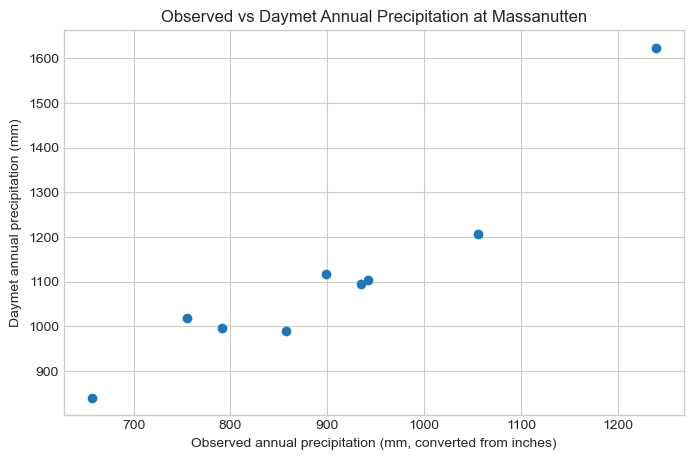

In [11]:
if daymet_mass is not None:
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.scatter(compare_annual['observed_prcp_mm_est'], compare_annual['daymet_prcp_mm'])
    ax.set_xlabel('Observed annual precipitation (mm, converted from inches)')
    ax.set_ylabel('Daymet annual precipitation (mm)')
    ax.set_title('Observed vs Daymet Annual Precipitation at Massanutten')
    plt.show()


## Valley vs Mountain Comparison

This compares Harrisonburg and Massanutten across the longer Daymet period.


In [12]:
if daymet_hbg is not None and daymet_mass is not None:
    annual_compare = hbg_annual.merge(mass_annual, on='year', suffixes=('_hbg', '_mass'))
    annual_compare['mountain_minus_valley_prcp_mm'] = annual_compare['annual_prcp_mm_mass'] - annual_compare['annual_prcp_mm_hbg']
    annual_compare['mountain_minus_valley_freezing_days'] = annual_compare['below_freezing_days_mass'] - annual_compare['below_freezing_days_hbg']
    display(annual_compare.head())


,year,annual_prcp_mm_hbg,mean_tmax_c_hbg,mean_tmin_c_hbg,below_freezing_days_hbg,annual_prcp_mm_mass,mean_tmax_c_mass,mean_tmin_c_mass,below_freezing_days_mass,mountain_minus_valley_prcp_mm,mountain_minus_valley_freezing_days
0,1980,874.96,17.736192,4.725315,124,951.86,17.123781,4.714384,124,76.90,0
1,1981,834.04,17.394356,4.324877,132,960.07,16.735644,4.252137,131,126.03,-1
2,1982,1084.15,17.785918,4.823781,118,1183.83,17.170575,4.776301,120,99.68,2
3,1983,1119.45,17.526767,4.585014,124,1234.95,16.970630,4.594521,120,115.50,-4
4,1984,1133.74,18.009562,5.499014,105,1227.41,17.445068,5.470438,106,93.67,1


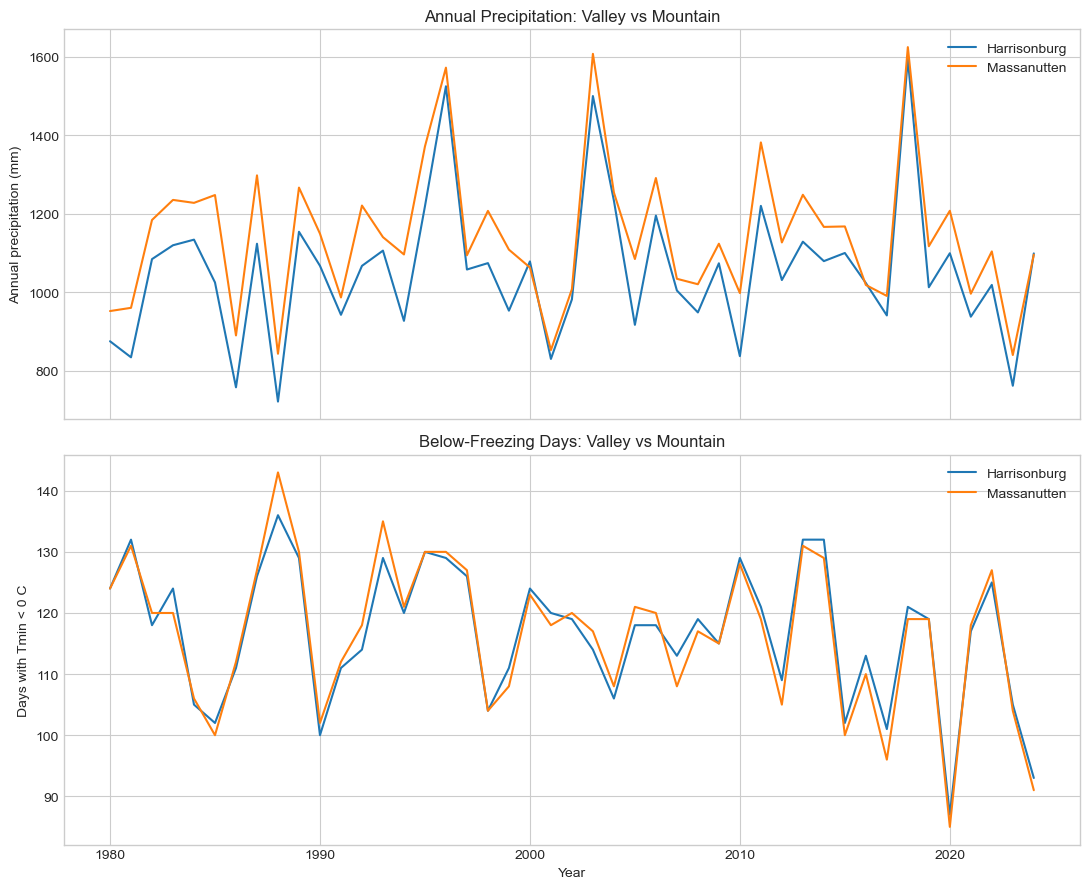

In [13]:
if daymet_hbg is not None and daymet_mass is not None:
    fig, axes = plt.subplots(2, 1, figsize=(11, 9), sharex=True)

    axes[0].plot(annual_compare['year'], annual_compare['annual_prcp_mm_hbg'], label='Harrisonburg')
    axes[0].plot(annual_compare['year'], annual_compare['annual_prcp_mm_mass'], label='Massanutten')
    axes[0].set_ylabel('Annual precipitation (mm)')
    axes[0].set_title('Annual Precipitation: Valley vs Mountain')
    axes[0].legend()

    axes[1].plot(annual_compare['year'], annual_compare['below_freezing_days_hbg'], label='Harrisonburg')
    axes[1].plot(annual_compare['year'], annual_compare['below_freezing_days_mass'], label='Massanutten')
    axes[1].set_ylabel('Days with Tmin < 0 C')
    axes[1].set_xlabel('Year')
    axes[1].set_title('Below-Freezing Days: Valley vs Mountain')
    axes[1].legend()

    plt.tight_layout()
    plt.show()


## Monthly Climatology

This helps answer the question about seasonality of precipitation.


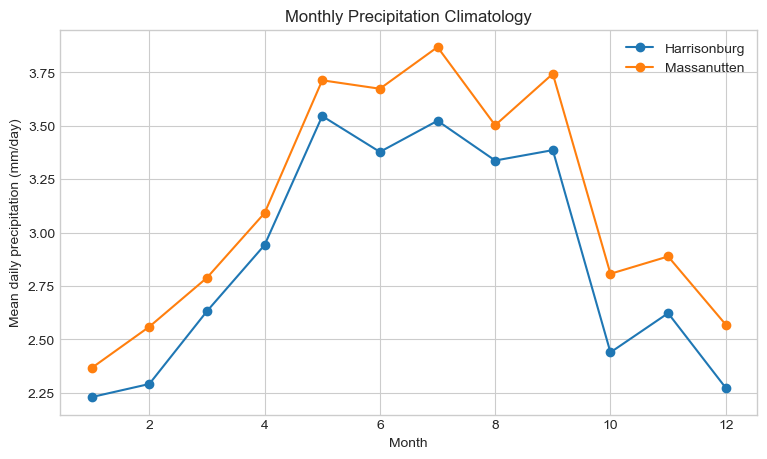

In [14]:
if daymet_hbg is not None and daymet_mass is not None:
    monthly_hbg = daymet_hbg.groupby('month', as_index=False).agg(mean_prcp_mm_day=('prcp_mm_day', 'mean'))
    monthly_mass = daymet_mass.groupby('month', as_index=False).agg(mean_prcp_mm_day=('prcp_mm_day', 'mean'))

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(monthly_hbg['month'], monthly_hbg['mean_prcp_mm_day'], marker='o', label='Harrisonburg')
    ax.plot(monthly_mass['month'], monthly_mass['mean_prcp_mm_day'], marker='o', label='Massanutten')
    ax.set_xlabel('Month')
    ax.set_ylabel('Mean daily precipitation (mm/day)')
    ax.set_title('Monthly Precipitation Climatology')
    ax.legend()
    plt.show()


## Interpretation Prompts

Use your figures and tables to answer these:
- How has long-term snowfall changed over time at the NOAA proxy station?
- How strongly does snowfall correlate with temperature change over time?
- How does the long-term regional snowfall signal compare with the short-term local Massanutten record?
- Does Massanutten receive more precipitation than Harrisonburg?
- Does Massanutten have more below-freezing days than Harrisonburg?
- Are winter conditions becoming less favorable for snow over time?
- Does Daymet match observed Massanutten precipitation well enough to support a 20+ year analysis?
- What do these results suggest about snow reliability at Massanutten?


## Results Paragraph

Using Daymet data from 1980 to 2024 and an observed Massanutten station record from 2016 to 2024, I found that Massanutten was slightly wetter than Harrisonburg over the long-term study period. Mean annual precipitation was about 1144 mm at Massanutten and about 1053 mm at Harrisonburg, which is a difference of about 90 mm per year. The overlap comparison between the observed station record and Daymet showed a strong year-to-year relationship, with a correlation of about 0.95, which suggests that Daymet captures interannual precipitation variability at Massanutten well enough to support a longer climate analysis.

For the snowfall questions, the workflow now uses a long-term NOAA proxy station because the direct Massanutten snowfall record in this project only begins in 2016. This makes it possible to evaluate how regional snowfall has changed over a much longer period and how those snowfall changes relate to temperature.


## Discussion Paragraph

The clearest climate signal in this analysis was warming winter conditions rather than a strong precipitation trend. Winter minimum temperatures increased at both Harrisonburg and Massanutten over the 1980 to 2024 period, and the number of below-freezing days declined at both locations. These patterns suggest that snow conditions may become less reliable over time, even if total annual precipitation remains fairly stable. In other words, the key issue for Massanutten may not be a major loss of precipitation, but that a greater share of winter precipitation may fall under warmer conditions that are less favorable for natural snowfall and snow retention.

The NOAA proxy section adds a second scale of analysis. It does not represent Massanutten snowfall perfectly, but it provides a defensible long-term regional snowfall record that can be compared with temperature over many decades. The short local Massanutten record can then be used to show how recent local snowfall fits within that broader regional climate context.


## Next Step

Download a NOAA daily file for `DALE ENTERPRISE, VA` (`USC00442208`) from Climate Data Online, save it as `Data/NOAA_DALE_ENTERPRISE_daily.csv`, and rerun the notebook to add the long-term snowfall trend and snowfall-temperature correlation analysis.
